In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import os

DB_PATH = '../backend/drone_tracking.db'
FIGURES_DIR = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)

engine = sqlalchemy.create_engine(f'sqlite:///{DB_PATH}')

try:
    df = pd.read_sql_table('detection', engine)
    print("✅ Data loaded successfully!")
    display(df.head())
except ValueError as e:
    print(f"❌ Error loading data: {e}")


✅ Data loaded successfully!


,id,daily_id,center_x,center_y,start_time,end_time,duration_seconds,detection_date,confidence
0,1,1,433,191,2025-09-29 16:18:11.429539,NaT,None,2025-09-29,0.5
1,2,2,430,139,2025-09-29 16:20:17.189178,NaT,None,2025-09-29,0.5
2,3,3,433,191,2025-09-29 16:21:16.778509,NaT,None,2025-09-29,0.5
3,4,4,430,139,2025-09-29 16:23:09.094606,NaT,None,2025-09-29,0.5
4,5,5,433,191,2025-09-29 16:24:22.525667,NaT,None,2025-09-29,0.5


In [8]:
# Preprocessing
if "start_time" in df.columns:
    df["start_time"] = pd.to_datetime(df["start_time"])
    df["date"] = df["start_time"].dt.date
    df["hour"] = df["start_time"].dt.hour
df.head()

,id,daily_id,center_x,center_y,start_time,end_time,duration_seconds,detection_date,confidence,date,hour
0,1,1,433,191,2025-09-29 16:18:11.429539,NaT,None,2025-09-29,0.5,2025-09-29,16
1,2,2,430,139,2025-09-29 16:20:17.189178,NaT,None,2025-09-29,0.5,2025-09-29,16
2,3,3,433,191,2025-09-29 16:21:16.778509,NaT,None,2025-09-29,0.5,2025-09-29,16
3,4,4,430,139,2025-09-29 16:23:09.094606,NaT,None,2025-09-29,0.5,2025-09-29,16
4,5,5,433,191,2025-09-29 16:24:22.525667,NaT,None,2025-09-29,0.5,2025-09-29,16


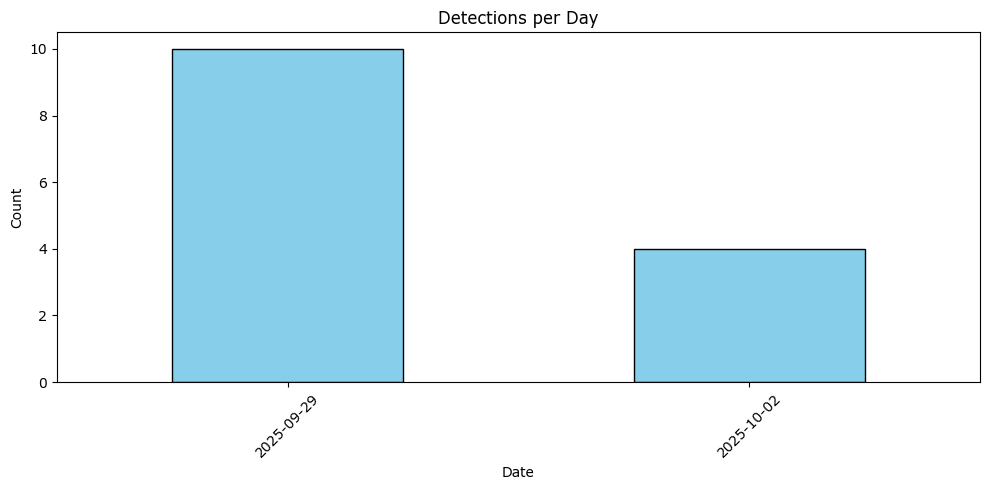

In [3]:
# 1. Detections per day
if "date" in df.columns:
    detections_per_day = df.groupby("date").size()
    plt.figure(figsize=(10,5))
    detections_per_day.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title("Detections per Day")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/detections_per_day.png")
    plt.show()

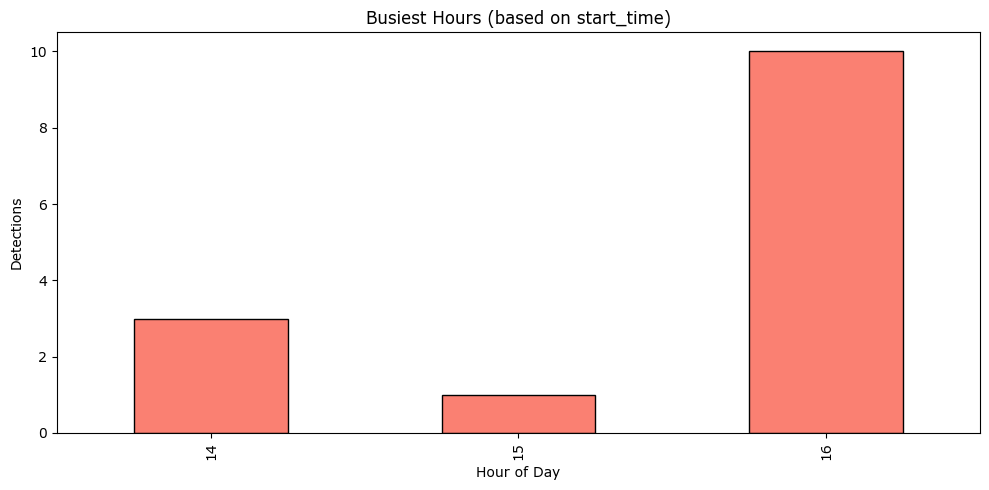

In [4]:
# 2. Busiest hours
# -------------------------------
if "hour" in df.columns:
    busiest_hours = df.groupby("hour").size()
    plt.figure(figsize=(10,5))
    busiest_hours.plot(kind="bar", color="salmon", edgecolor="black")
    plt.title("Busiest Hours (based on start_time)")
    plt.xlabel("Hour of Day")
    plt.ylabel("Detections")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/busiest_hours.png")
    plt.show()

In [5]:
# 3. Avg confidence + avg duration
if "confidence" in df.columns:
    avg_conf = df["confidence"].mean()
    print(f"📊 Average Confidence: {avg_conf:.2f}")

if "duration" in df.columns:
    avg_dur = df["duration"].mean()
    print(f"⏱ Average Duration: {avg_dur:.2f} seconds")


📊 Average Confidence: 0.50


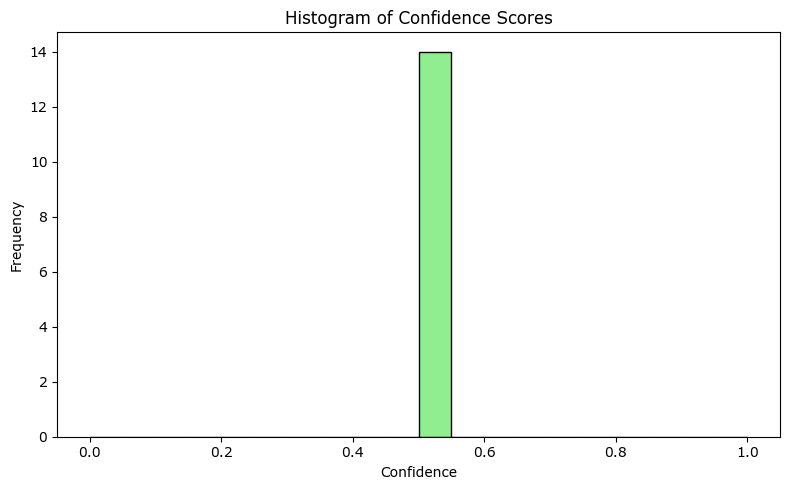

In [6]:
# 4. Histogram of confidence
if "confidence" in df.columns:
    plt.figure(figsize=(8,5))
    plt.hist(df["confidence"], bins=20, edgecolor="black", color="lightgreen")
    plt.title("Histogram of Confidence Scores")
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/confidence_histogram.png")
    plt.show()

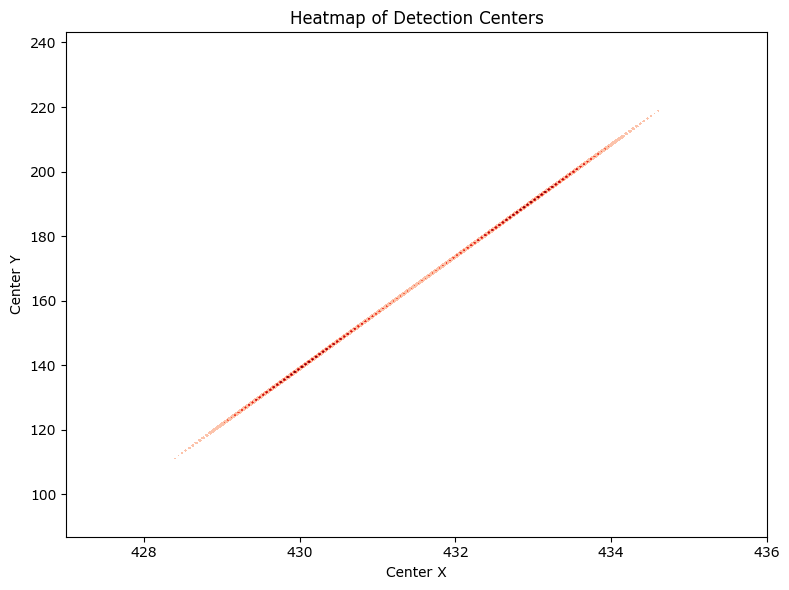

In [7]:
# 5. Heatmap (center_x, center_y)
if "center_x" in df.columns and "center_y" in df.columns:
    plt.figure(figsize=(8,6))
    sns.kdeplot(
        x=df["center_x"], 
        y=df["center_y"], 
        fill=True, 
        cmap="Reds", 
        thresh=0.05
    )
    plt.title("Heatmap of Detection Centers")
    plt.xlabel("Center X")
    plt.ylabel("Center Y")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/detection_heatmap.png")
    plt.show()